# DAF-15: Tree and Ensemble Models

## The story

Asha's Ridge model draws one straight line through her features. It beat persistence a little, but it treats every day the same way: one weight for wind, one weight for last week's average, whatever the month.

Asha knows Delhi does not work like that. A calm day in November traps smoke and can push PM2.5 very high. A calm day in July barely matters, because the monsoon washes the air. A straight line cannot say "it depends on the season". A model made of `if / else` rules can.

So she asks one question: **does a non-linear model beat Ridge on this data, or does it only look clever?** DAF-15 answers it with evidence, not fashion.

## What this ticket is about

Until now every model was a formula: multiply each feature by a weight and add them up. DAF-15 tries models that work by asking questions instead.

```text
Ridge (a formula)                     Decision tree (rules)
price = 3*a + 2*b + 5*c               if wind < 4:
                                          if month is Oct-Nov: predict high
                                          else: predict medium
                                      else: predict low
```

Backend analogy: Ridge is one arithmetic expression. A tree is a chain of `if / else` statements that the computer writes for itself by studying the training rows.

## The three models

| Model | How it works, in one line | Strength | Watch for |
|---|---|---|---|
| `DecisionTreeRegressor` | One tree of if/else rules | Readable: you can print the rules it learned | Memorises the training rows. A teaching model |
| `RandomForestRegressor` | Many trees, each trained on a random slice of the data, then averaged | Robust, needs little tuning | Cannot predict above the largest target it has seen |
| `HistGradientBoostingRegressor` | Trees built one after another, each fixing the mistakes of the ones before | Usually the strongest on tables | More settings; overfits small data if unchecked |

Trees do not need scaling. We still keep each one inside a `Pipeline`, so every model in the project has the same `fit` / `predict` interface as Ridge.

## The main danger: memorising

We have only about 283 training rows. A tree can learn every one of them perfectly and still fail on the next 90 days.

```text
                   train MAE      test MAE      what it means
learned the pattern    low          low         good
memorised the rows     very low     high        overfit: the gap gives it away
too simple             high         high        underfit
```

So for every model we report **train MAE and test MAE side by side**. The size of the gap matters as much as the test score. Explain-back question 1 is about exactly this.

## Rules for this ticket

- Same chronological cut as before: train before **2026-03-01**, test from 2026-03-01.
- Same features as the best DAF-14 row, so the only thing that changes is the model.
- **Default settings only.** No hyper-parameter is chosen by looking at the test score. DAF-17 tunes properly with `TimeSeriesSplit`.
- The bar to beat, from the experiment log:

| Row | Test MAE | Recall on Poor days |
|---|---|---|
| Persistence | 15.728 | 0.471 |
| `daf14_lags` (Ridge) | 15.387 | 0.412 |
| `daf14_selected` (Ridge) | 15.588 | 0.706 |

## The plan, one step at a time

1. Load the table and rebuild the same train/test split and features as DAF-14.
2. Fit the three models with default settings. Report train MAE, test MAE and recall for each.
3. Plot a depth-3 decision tree and read its first two splits in words.
4. Add three rows to `reports/experiments.csv`.
5. Name the best model so far, with the numbers that make it best.

We will do one step at a time. Step 1 comes next.

# Step 1 — Rebuild the DAF-14 table and split

## 🎬 How we got here

DAF-14 ended with a named feature set: `pm25_until_17`, `mean_3`, `mean_7` and `mean_14`. Ridge, a straight-line model, scored MAE 15.588 and caught 12 of the 17 Poor days with it. Now Asha wants to know whether a tree-based model can beat that.

## 😖 The problem

Comparing models is only fair if every model sees exactly the same days and the same inputs. Suppose the random forest were trained on a different cut date, or on more rows. If it scored better, Asha could not tell whether the model was better or the data was easier.

```text
Unfair                                   Fair
Ridge:   cut 2026-03-01, 4 features      Ridge:   cut 2026-03-01, 4 features
Forest:  cut 2026-01-01, 18 features     Forest:  cut 2026-03-01, 4 features
   |                                        |
   v                                        v
"Forest wins" - but why?                 only the model changed
```

There is also a leakage trap. If Asha picked the feature set by looking at which one made a tree score best on the test rows, the test rows would have helped choose the features. The features must be fixed **before** any tree is fitted.

## 💡 The idea

Rebuild the table once, exactly as DAF-14 did, and reuse it for all three models:

```text
daily_17.csv
     |
     v
add rolling features (yesterday-based, so knowable at 18:00)
     |
     v
keep the 4 fixed features + target, drop rows with gaps
     |
     +--> train: before 2026-03-01   (251 rows)
     +--> test:  from 2026-03-01     (130 rows)
```

The backend analogy: this is a fixed test fixture. Before you compare two implementations, you freeze the input data and the harness, so the only thing that changes is the code under test.

## 🔍 What this actually is

- **Which features:** `daf14_selected` was the DAF-14 row with the highest Poor-day recall (0.706). Asha's job is to warn about Poor days, so that row is the one to beat. The row with the lowest MAE, `daf14_lags`, was only 0.2 better and caught far fewer Poor days.
- **The guard:** the code asserts 251 train rows and 130 test rows. Those are DAF-14's numbers. If they ever differ, the rebuild is wrong and the notebook stops.
- **Nothing is fitted yet.** This step only prepares the data.

### 🤔 Before you run the code

The train period includes the Delhi winter, and the test period is March to August. Do you expect the share of Poor days to be the same in both? Predict first, then read the counts.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

from delhi_air.clean import add_rolling_features  # our own function from src/delhi_air/clean.py

# --- 1. Find the project folder ---------------------------------------------
# The notebook can be opened from the repo root or from the project folder.
# Walk up from the current folder until we find the folder that holds the data.
project_root = next(
    (
        candidate
        for candidate in (Path.cwd(), *Path.cwd().parents)
        if (candidate / "18_Projects/01_Delhi_Air_Forecast/data/interim/daily_17.csv").is_file()
        or (candidate / "data/interim/daily_17.csv").is_file()
    ),
    None,  # if nothing matches, next() gives None instead of crashing
)
if project_root is None:
    raise FileNotFoundError("Could not find data/interim/daily_17.csv from this notebook's working directory.")

# Two cases: we are already inside the project folder, or we are at the repo root.
# Either way, data_root ends up pointing at the project's data/ folder.
if (project_root / "data/interim/daily_17.csv").is_file():
    data_root = project_root / "data"
else:
    data_root = project_root / "18_Projects/01_Delhi_Air_Forecast/data"

# --- 2. The two settings that must never change in this ticket ---------------
cut_date = pd.Timestamp("2026-03-01")  # rows before this are train, rows from it are test
poor_threshold = 91                    # PM2.5 at or above this counts as a "Poor" day

# --- 3. Load the daily table --------------------------------------------------
# One row per day. The date becomes the index so we can slice by time.
daily = pd.read_csv(
    data_root / "interim/daily_17.csv",
    parse_dates=["date"],
    index_col="date",
)
# Make every date a plain calendar day in Delhi time (no timezone, no clock time),
# so that "2026-03-01" means the same day everywhere in the notebook.
if daily.index.tz is not None:
    daily.index = daily.index.tz_convert("Asia/Kolkata").tz_localize(None)
daily.index = daily.index.normalize()

# --- 4. Fix the features BEFORE any model is fitted -----------------------------
# These four are the final DAF-14 set. Writing them down here, by hand, means the
# test rows can never influence which features we use.
feature_names = ["pm25_until_17", "mean_3", "mean_7", "mean_14"]

# --- 5. Build the features ------------------------------------------------------
# add_rolling_features adds mean_3, mean_7, mean_14 (plus std_7, max_7).
# Each one is calculated from YESTERDAY and earlier, because today's full-day value
# is not finished at 18:00, when Asha makes her prediction.
with_rolling = add_rolling_features(daily)

# Keep only what the models need: the 4 features and the target (tomorrow's PM2.5).
# dropna() removes every day that has an empty value in any kept column. Empty values
# come from gaps in the sensor data (a missing day breaks every rolling window that
# covers it, and mean_14 needs 14 clean days in a row), from the start of the table,
# and from the last day, which has no "tomorrow" yet. It leaves the same 251 + 130
# rows as DAF-14. The printout below shows how many rows each column cost us.
keep_columns = feature_names + ["target"]
model_table = with_rolling[keep_columns].dropna()

# Show exactly what was added and what was dropped.
added_columns = [name for name in with_rolling.columns if name not in daily.columns]
dropped_columns = [name for name in with_rolling.columns if name not in keep_columns]
dropped_rows = with_rolling.index.difference(model_table.index)
print("columns added by add_rolling_features:", added_columns)
print("columns dropped (not needed):        ", dropped_columns)
print(f"rows before dropna: {len(with_rolling)}, after: {len(model_table)}, dropped: {len(dropped_rows)}")
# Why each row was dropped: which of the kept columns is empty on that day?
why_dropped = with_rolling.loc[dropped_rows, keep_columns].isna()
print("rows dropped because of each empty column:")
print(why_dropped.sum()[why_dropped.sum() > 0].to_string())
print("first dropped day:", dropped_rows.min().date(), "| last dropped day:", dropped_rows.max().date())

# --- 6. Split by TIME, never at random ---------------------------------------------
# Train on the past, test on the future, like real life. A random split would let the
# model peek at days on both sides of a test day.
train = model_table.loc[model_table.index < cut_date]
test = model_table.loc[model_table.index >= cut_date]

# --- 7. Safety checks: stop loudly if something is wrong ------------------------------
# No NaN or infinity anywhere in the inputs.
assert np.isfinite(train[feature_names].to_numpy()).all()
assert np.isfinite(test[feature_names].to_numpy()).all()
# Same row counts as the DAF-14 selected row, so the comparison with Ridge is fair.
assert (len(train), len(test)) == (251, 130), "rows differ from the DAF-14 selected row"

# --- 8. Look at what we built ---------------------------------------------------------
print(f"train: {len(train)} rows, {train.index.min().date()} to {train.index.max().date()}")
print(f"test:  {len(test)} rows, {test.index.min().date()} to {test.index.max().date()}")
print(f"Poor days (target >= {poor_threshold}): {int((train['target'] >= poor_threshold).sum())} train, {int((test['target'] >= poor_threshold).sum())} test")
display(train.head(3).round(1))  # first three training rows: 4 features + the target

columns added by add_rolling_features: ['mean_3', 'mean_7', 'mean_14', 'std_7', 'max_7']
columns dropped (not needed):         ['pm25_mean', 'hours', 'valid', 'std_7', 'max_7']
rows before dropna: 571, after: 381, dropped: 190
rows dropped because of each empty column:
pm25_until_17     21
mean_3            38
mean_7            74
mean_14          135
target            84
first dropped day: 2025-02-19 | last dropped day: 2026-09-12
train: 251 rows, 2025-03-17 to 2026-02-28
test:  130 rows, 2026-03-01 to 2026-08-25
Poor days (target >= 91): 117 train, 17 test


,pm25_until_17,mean_3,mean_7,mean_14,target
date,,,,,
2025-03-17,64.3,53.9,84.6,75.1,69.1
2025-03-18,76.5,46.3,79.5,75.5,76.7
2025-03-19,80.8,58.0,71.0,76.9,70.9


### Read the result

The rebuild matches DAF-14's selected row exactly, so the comparison is fair.

| Split | Rows | Dates | Poor days | Share Poor |
|---|---:|---|---:|---:|
| Train | 251 | 2025-03-17 to 2026-02-28 | 117 | 47% |
| Test | 130 | 2026-03-01 to 2026-08-25 | 17 | 13% |

Two things to notice:

- **The halves are different.** Nearly half of the training days are Poor, but only about one in eight test days is. The train period contains a whole winter and the test period is spring and summer. Any gap between train and test error in Step 2 is partly memorising and partly this season change.
- **Recall rests on 17 days.** One Poor day is worth about 0.06 of recall, so small differences between models mean little.

The sample table shows the shape the models will see: three level summaries and today's partial reading, all measured in the same units, with tomorrow's PM2.5 as the target.

## Before Step 2

Step 1 froze the data. Step 2 fits the decision tree, the random forest and the gradient-boosting model with default settings, and reports train MAE, test MAE and recall for each. The train/test gap is the number to watch.

# Step 2 — Fit the three models with default settings

## 🎬 How we got here

Step 1 froze the data: 251 train days, 130 test days, four fixed features. Ridge scored MAE 15.588 on those test days. Now the three tree models take the same exam.

## 😖 The problem

A tree model can look brilliant and be useless. Suppose a decision tree scores an average error of 2 on the training days. That sounds excellent. But if it scores 20 on the test days, it did not learn a pattern. It memorised 251 answers, like a student who learned last year's exam paper by heart.

```text
Model A                        Model B
train MAE  9                    train MAE  2
test  MAE 15                    test  MAE 18
gap        6                    gap       16   <- memorised the rows
```

Test MAE alone hides this. Model B's train score looks great, and only the gap shows it failed to generalise.

## 💡 The idea

Fit all three models the same way and score each one **twice**, on the days it studied and on the days it never saw:

```text
        the same 4 features, the same cut date
                        |
     +------------------+------------------+
     |                  |                  |
Decision tree     Random forest     Gradient boosting
     |                  |                  |
     +--> train MAE, test MAE, Poor-day recall for each
                        |
                 gap = test MAE - train MAE
```

- **Decision tree:** one chain of `if / else` rules.
- **Random forest:** 100 trees, each trained on a random sample of the days, then averaged. Averaging calms down any single tree's memorising.
- **Gradient boosting:** trees built in turn, each one trained to fix the mistakes left by the trees before it.

## 🔍 What this actually is

- **Defaults only.** No setting is chosen by looking at the test score. That is DAF-17's job, with proper time-ordered cross-validation.
- **`random_state=0`** is not tuning. The forest and the tree pick random samples and break ties at random, and a fixed seed makes the notebook give the same numbers every time it runs.
- **No scaling.** A tree asks "is `mean_7` above 80?", so the unit of the number does not matter. We still use a `Pipeline` so every model in the project has the same `fit` / `predict` interface as Ridge.
- **Recall** means: of the 17 truly Poor days in the test set, how many did the model warn about (predicted at or above 91)?

### 🤔 Before you run the code

Which model will have the biggest gap between train and test MAE? Which will have the smallest? Predict first, then compare the measured result.

In [2]:
import warnings

from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, recall_score
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor

# Continues from Step 1: same train / test tables, same feature_names, same poor_threshold.

# --- 1. The three models, all with DEFAULT settings -------------------------------
# The only thing we set is random_state, so the results are the same on every run.
# Each model sits inside a Pipeline (one step only) so it has the same fit / predict
# interface as the Ridge pipeline from DAF-14. Trees need no scaling, so no scaler.
models = {
    "decision_tree": Pipeline([("model", DecisionTreeRegressor(random_state=0))]),
    "random_forest": Pipeline([("model", RandomForestRegressor(random_state=0))]),
    "hist_gradient_boosting": Pipeline([("model", HistGradientBoostingRegressor(random_state=0))]),
}


# --- 2. One scoring function used for train AND test -------------------------------
def score(pipe, table):
    # Predict for every day in this table, then compare with the real target.
    predictions = pipe.predict(table[feature_names])
    actual_poor = table["target"] >= poor_threshold      # was the day really Poor?
    predicted_poor = predictions >= poor_threshold        # did the model warn?
    return {
        "mae": mean_absolute_error(table["target"], predictions),
        # recall = Poor days caught / all real Poor days
        "recall_poor": recall_score(actual_poor, predicted_poor, zero_division=0),
        "poor_caught": int((actual_poor & predicted_poor).sum()),
    }


# --- 3. Fit on TRAIN only, then score on train and on test ---------------------------
step2_results = []
for name, pipe in models.items():
    pipe.fit(train[feature_names], train["target"])   # the only place a model sees data
    on_train = score(pipe, train)                       # days it studied
    on_test = score(pipe, test)                         # days it never saw
    step2_results.append(
        {
            "model": name,
            "train_mae": on_train["mae"],
            "test_mae": on_test["mae"],
            "gap": on_test["mae"] - on_train["mae"],    # big gap = memorised the rows
            "test_recall": on_test["recall_poor"],
            "poor_caught_of_17": on_test["poor_caught"],
        }
    )

step2_table = pd.DataFrame(step2_results).set_index("model")
display(step2_table.round(3))

# For reference, the Ridge row from DAF-14 (same days, same features).
print("Ridge (daf14_selected): test MAE 15.588, recall 0.706 (12 of 17 Poor days)")

,train_mae,test_mae,gap,test_recall,poor_caught_of_17
model,,,,,
decision_tree,0.000,25.092,25.092,0.647,11
random_forest,11.834,18.900,7.066,0.529,9
hist_gradient_boosting,19.132,19.728,0.596,0.294,5


Ridge (daf14_selected): test MAE 15.588, recall 0.706 (12 of 17 Poor days)


### Read the result

| Model | Train MAE | Test MAE | Gap | Poor days caught (of 17) | Recall |
|---|---:|---:|---:|---:|---:|
| Decision tree | 0.000 | 25.092 | 25.092 | 11 | 0.647 |
| Random forest | 11.834 | 18.900 | 7.066 | 9 | 0.529 |
| Gradient boosting | 19.132 | 19.728 | 0.596 | 5 | 0.294 |
| *Ridge, from DAF-14* | *not shown here* | *15.588* | *not shown here* | *12* | *0.706* |

**No tree model beat Ridge on average error.** The best of the three, the random forest, misses by 18.9 on average against Ridge's 15.6. Persistence, the simple "tomorrow looks like today" rule, scores 16.8 on these same 130 days (Step 4 re-scores it). So all three are worse than doing almost nothing.

Each model tells a different story:

- **Decision tree: pure memorising.** Train MAE is exactly 0.000. With no limit on depth, the tree kept splitting until every one of the 251 training days had its own leaf, so it "knows" every training answer. On new days it is the worst of the three (25.1). The gap of 25 is the textbook overfit.
- **Random forest: memorises less.** Averaging 100 trees calms the memorising, but the gap is still 7.1. Its train error (11.8) is much lower than its test error (18.9).
- **Gradient boosting: barely memorised, and barely learned.** The gap is tiny (0.6), but train MAE is 19.1, which is no better than test. That is not a healthy model. It is a cautious one that fits the training days poorly too. It also caught only 5 of 17 Poor days.

Two things to keep in mind before judging trees:

- **The two halves are different seasons.** Step 1 showed 47% of training days are Poor, against 13% of test days. Part of every gap here comes from that change, not only from memorising.
- **A forest cannot predict above the highest target it saw.** Training has many very high winter days, so this limit is probably not what hurts on spring and summer test days. It matters in the other direction, when a worse winter than any before arrives. That is explain-back question 2.

The decision tree caught 11 Poor days despite a terrible MAE, but a model that warns often and is wrong about the size of the pollution is not a good forecast. Step 3 draws a small tree so we can read the rules it actually learned.

# Step 3 — Draw a small tree and read its rules

## 🎬 How we got here

Step 2 showed that the unlimited decision tree memorised the training days (train MAE 0.000) and did worst on new ones. But a tree has one big advantage over Ridge and the forest: you can read it. Before we decide whether trees are worth keeping, Asha wants to see what a tree actually *asks*.

## 😖 The problem

The tree from Step 2 has hundreds of leaves. Nobody can read that. A tree with a hundred rules is as opaque as any other black box, so its readability advantage is gone.

```text
Unlimited tree (Step 2)               Depth-3 tree
~250 leaves, one per day              at most 8 leaves
"if a and b and c and d and ..."      "if A: if B: if C: predict X"
cannot be read                        fits on one page
```

## 💡 The idea

Limit the tree to **depth 3**, which means at most three questions in a row before it gives an answer. Then draw it.

```text
                 [ feature A <= cut 1 ? ]            <- question 1 (the root)
                  yes /              \ no
      [ feature B <= cut 2 ? ]    [ feature C <= cut 3 ? ]   <- question 2
            /      \                 /      \
          ...      ...             ...      ...       <- question 3, then leaves
```

*(This sketch is only the shape. The real features and cut points come from the data.)*

Each box shows the question, how many training days reached it (`samples`), and their average PM2.5 (`value`). At the bottom, `value` is the tree's prediction. `squared_error` is how spread out the days in that box are: a small number means they are alike.

## 🔍 What this actually is

- **Depth 3 is a teaching choice, not a tuned setting.** The ticket asks for it so the picture is readable. We do not compare its score with the other models to pick a winner.
- **Fitted on train rows only**, with the same four features.
- **How a tree picks a question:** it tries every feature and every cut point, and keeps the one that makes the two groups most alike in PM2.5. In backend words, it is a greedy search for the best `WHERE` clause.
- The tree also gives the exact rules as text, so we can read them without squinting at the picture.

### 🤔 Before you run the code

Which of the four features will the tree ask about first? Predict first, then compare with the picture.

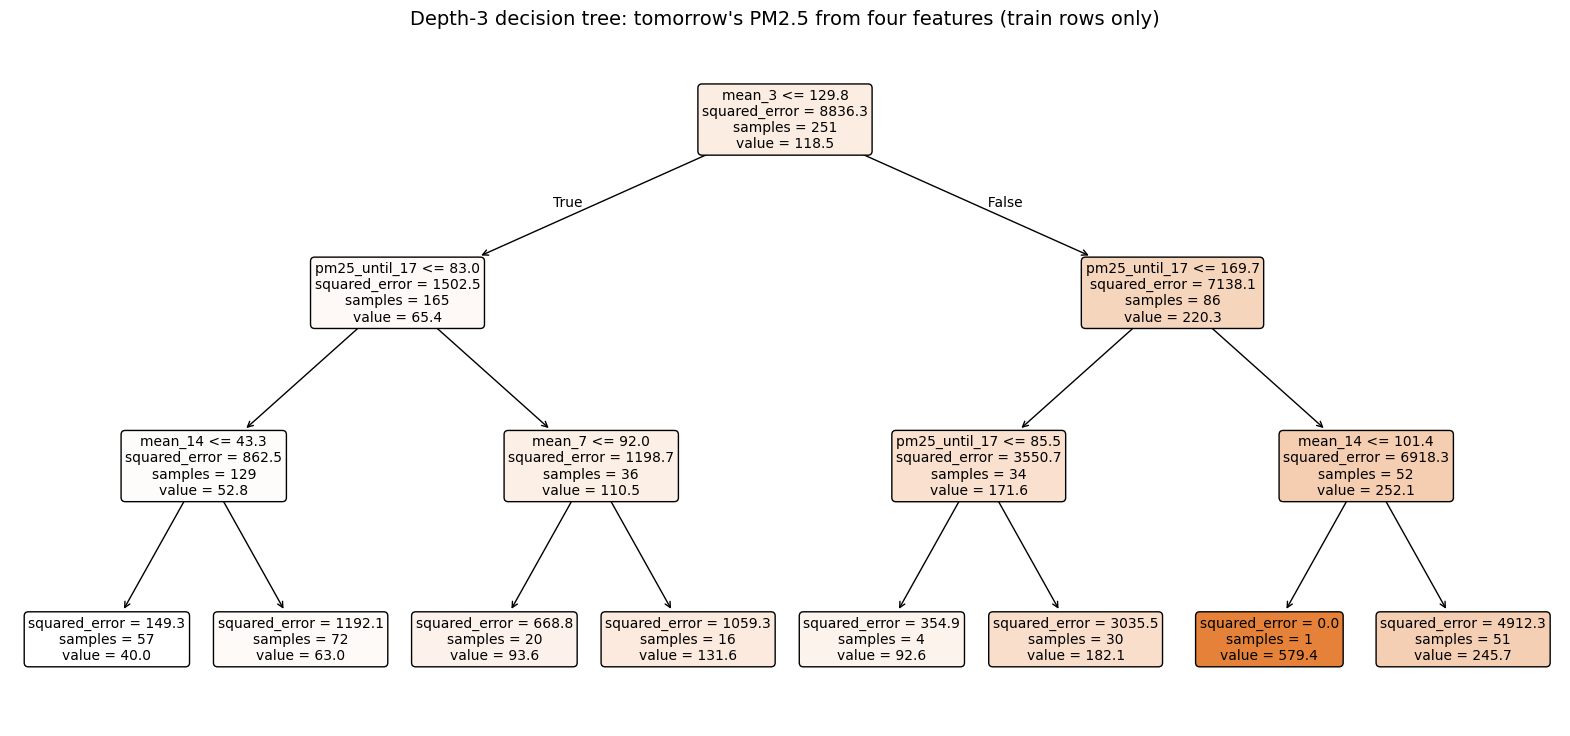

|--- mean_3 <= 129.8
|   |--- pm25_until_17 <= 83.0
|   |   |--- mean_14 <= 43.3
|   |   |   |--- value: [40.0]
|   |   |--- mean_14 >  43.3
|   |   |   |--- value: [63.0]
|   |--- pm25_until_17 >  83.0
|   |   |--- mean_7 <= 92.0
|   |   |   |--- value: [93.6]
|   |   |--- mean_7 >  92.0
|   |   |   |--- value: [131.6]
|--- mean_3 >  129.8
|   |--- pm25_until_17 <= 169.7
|   |   |--- pm25_until_17 <= 85.5
|   |   |   |--- value: [92.6]
|   |   |--- pm25_until_17 >  85.5
|   |   |   |--- value: [182.1]
|   |--- pm25_until_17 >  169.7
|   |   |--- mean_14 <= 101.4
|   |   |   |--- value: [579.4]
|   |   |--- mean_14 >  101.4
|   |   |   |--- value: [245.7]

share of the tree's work done by each feature:
pm25_until_17    0.146
mean_3           0.775
mean_7           0.007
mean_14          0.072


In [3]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, export_text, plot_tree

# Continues from Steps 1 and 2: same train table, same feature_names.

# --- 1. A small tree: at most 3 questions in a row -------------------------------
# max_depth=3 is chosen so the picture is readable, not by looking at any score.
# It is fitted on TRAIN rows only, like every model in this notebook.
small_tree = DecisionTreeRegressor(max_depth=3, random_state=0)
small_tree.fit(train[feature_names], train["target"])

# --- 2. Draw it ---------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(20, 9))
plot_tree(
    small_tree,
    feature_names=feature_names,
    filled=True,        # darker box = higher predicted PM2.5
    rounded=True,
    precision=1,
    fontsize=10,
    ax=ax,
)
ax.set_title("Depth-3 decision tree: tomorrow's PM2.5 from four features (train rows only)", fontsize=14)
figure_dir = data_root.parent / "notebooks/figures"
figure_dir.mkdir(exist_ok=True)
fig.savefig(figure_dir / "15_depth3_tree.png", dpi=150, bbox_inches="tight")
plt.show()

# --- 3. The same tree as plain text rules -----------------------------------------------
# Each line is one question. Indentation shows the branch. 'value' is the predicted PM2.5.
print(export_text(small_tree, feature_names=feature_names, decimals=1))

# --- 4. Which features did the tree actually use? ------------------------------------------
# 0 means the tree never asked about that feature.
importances = pd.Series(small_tree.feature_importances_, index=feature_names)
print("share of the tree's work done by each feature:")
print(importances.round(3).to_string())

### Read the result

The picture is saved as `notebooks/figures/15_depth3_tree.png`. Read it from the top.

**Question 1 (the root): is `mean_3` at most 129.8?**
`mean_3` is the average PM2.5 of the last three completed days. The tree splits the 251 training days into two very different groups:

| Answer | Days | Average PM2.5 tomorrow |
|---|---:|---:|
| Yes, the last three days were fairly clean | 165 | 65.4 |
| No, the last three days were very polluted | 86 | 220.3 |

In words: *if the air has been bad for three days, tomorrow is very likely bad too.* That is the same idea as persistence, and the tree found it on its own. The whole training average is 118.5, so this one question separates "about 65" from "about 220".

**Question 2: how high is today so far (`pm25_until_17`)?**
Both branches now ask about **today so far**, with different cut points:

| Branch | Question | Yes | No |
|---|---|---|---|
| Recent days clean | `pm25_until_17` <= 83.0 | 129 days, average 52.8 | 36 days, average 110.5 |
| Recent days polluted | `pm25_until_17` <= 169.7 | 34 days, average 171.6 | 52 days, average 252.1 |

In words: *within each group, if today is also worse than usual for that group, tomorrow will be worse too.* After two questions the tree already has four groups, from an average of 52.8 up to 252.1.

**How much each feature did.** `mean_3` did 77.5% of the tree's work, `pm25_until_17` 14.6%, `mean_14` 7.2% and `mean_7` only 0.7%. The four features overlap heavily, so once `mean_3` is used, `mean_7` adds almost nothing.

**A warning sign in the last row.** One leaf on the far right holds a **single training day** with PM2.5 579.4. The tree carved out a leaf just for that one day. This is a small version of the memorising we saw in Step 2. Even at depth 3, a tree will build a box around one extreme day if that reduces its error.

**What the tree cannot tell us.** It has no rule like "low wind in November". Our four features are all PM2.5 history, so all it can learn is levels of recent pollution. That limit comes from the features, not from the tree.

### What we are trying to understand in Step 3

Step 2 told us **that** the trees are worse than Ridge. Step 3 shows **why**, by opening a tree and reading it.

```text
Ridge                              Decision tree
one formula                        a list of if / else questions
hard to read as rules              easy to read: you can see every question
```

**What the tree learned.** Its first two questions were "were the last 3 days very polluted?" and "is today so far also high?". That is the persistence idea: *if the air is bad now, tomorrow is probably bad*. It found this by itself.

**Why that is not enough.** We tried trees because they can learn conditions a straight line cannot, like "low wind matters more in November". But all four of our features are past PM2.5. With only those, the tree can learn recent pollution levels and nothing else. So on these features it gives no benefit over Ridge.

**The one risk it showed.** A tree can build a box around a single day (the leaf with one day at 579.4). That is the same over-fitting we saw in Step 2, in a smaller form.

In one line: *a tree is only as smart as the features it is given, and it will memorise if nothing stops it.*

# Step 4 — Record the three models and name the best one so far

## 🎬 How we got here

Steps 2 and 3 scored the three tree models and read one tree. The numbers so far exist only inside this notebook. If we close it, they are gone, and in a month nobody will remember how a forest compared with Ridge.

## 😖 The problem

A result that is not written down cannot be compared later. DAF-16 will change the metric and DAF-17 will tune the models. Without one line per experiment, the project cannot say what it tried, what beat what, or why the final model was chosen.

There is also a naming problem. "The best model so far" sounds simple, but there are two scores: average miss (MAE) and Poor days caught (recall). One model can win one and lose the other.

## 💡 The idea

Add one row per model to `reports/experiments.csv`, the same file used since DAF-06, then put every candidate side by side:

```text
Step 2 table ──► 3 new rows in the experiment log
                          |
                          v
       persistence, Ridge rows, 3 tree rows: one comparison
                          |
                          v
              name the best model, with the numbers
```

Backend analogy: the experiment log is the changelog plus the benchmark history. You do not trust a performance claim that is not in it.

## 🔍 What this actually is

- **The row holds test MAE and test recall**, like every earlier row. Train MAE and the gap go in the `notes` column, so the overfitting is on record too.
- **The code is safe to re-run.** It removes any earlier row with the same model name before adding the new one, so running it twice does not create duplicates.
- **How we name "best".** MAE and recall are both shown. We pick the model that is close to the best on average error and clearly best on catching Poor days, because that is Asha's job.
- **No setting is chosen from the test score here.** We are only recording and comparing.

### 🤔 Before you run the code

Do you expect any tree model to make the top of the table? Predict first, then compare.

In [4]:
# Continues from Step 2: step2_table (one row per model), train, test, cut_date, feature_names.

# --- 1. Turn the Step 2 table into experiment-log rows --------------------------------
log_path = data_root.parent / "reports/experiments.csv"
log_columns = ["ticket", "date", "model", "features", "mae", "recall_poor", "notes"]

new_rows = []
for model_name, row in step2_table.iterrows():
    new_rows.append(
        {
            "ticket": "DAF-15",
            "date": pd.Timestamp.today().strftime("%Y-%m-%d"),
            "model": f"daf15_{model_name}",
            "features": ", ".join(feature_names),
            "mae": round(row["test_mae"], 3),
            "recall_poor": round(row["test_recall"], 3),
            # Train MAE and the gap go in the notes, so the overfitting is on record too.
            "notes": (
                f"default settings, random_state=0, no scaling; train MAE {row['train_mae']:.3f}, "
                f"gap {row['gap']:.3f}; caught {int(row['poor_caught_of_17'])} of 17 Poor days; "
                f"same cut {cut_date.date()}; {len(train)} train / {len(test)} test rows"
            ),
        }
    )
new_rows = pd.DataFrame(new_rows, columns=log_columns)

# --- 2. Write them, safe to re-run ------------------------------------------------------
# Drop any earlier row with the same model name first, so re-running does not duplicate.
experiment_log = pd.read_csv(log_path)
experiment_log = experiment_log.loc[~experiment_log["model"].isin(new_rows["model"])]
experiment_log = pd.concat([experiment_log, new_rows], ignore_index=True)
experiment_log[log_columns].to_csv(log_path, index=False)
print(f"Wrote {len(new_rows)} DAF-15 rows to {log_path}")

# --- 3. One fair comparison on the SAME 130 test days -----------------------------------
# Rows in the log from earlier tickets were scored on different test days (145 or 161),
# so putting them side by side would not be fair. We keep only the DAF-14 selected row,
# which used exactly these 251 / 130 rows, and we re-score persistence on these 130 days:
# "tomorrow = today so far" is just the pm25_until_17 column used as the prediction.
persistence_prediction = test["pm25_until_17"]
persistence_row = pd.DataFrame(
    {
        "mae": [mean_absolute_error(test["target"], persistence_prediction)],
        "recall_poor": [
            recall_score(
                test["target"] >= poor_threshold,
                persistence_prediction >= poor_threshold,
                zero_division=0,
            )
        ],
    },
    index=["persistence (re-scored here)"],
)

compare_models = [
    "daf14_selected",
    "daf15_decision_tree",
    "daf15_random_forest",
    "daf15_hist_gradient_boosting",
]
same_rows = experiment_log.loc[experiment_log["model"].isin(compare_models)].set_index("model")[["mae", "recall_poor"]]
comparison = pd.concat([persistence_row, same_rows.loc[compare_models]])
comparison["poor_caught_of_17"] = (comparison["recall_poor"] * int((test["target"] >= poor_threshold).sum())).round().astype(int)
display(comparison.sort_values("mae").round(3))
print("lowest MAE:      ", comparison["mae"].idxmin(), round(comparison["mae"].min(), 3))
print("highest recall:  ", comparison["recall_poor"].idxmax(), round(comparison["recall_poor"].max(), 3))


Wrote 3 DAF-15 rows to /Users/kaliprasad/Documents/MACHINE_LEARNING/18_Projects/01_Delhi_Air_Forecast/reports/experiments.csv


,mae,recall_poor,poor_caught_of_17
daf14_selected,15.588,0.706,12
persistence (re-scored here),16.791,0.471,8
daf15_random_forest,18.900,0.529,9
daf15_hist_gradient_boosting,19.728,0.294,5
daf15_decision_tree,25.092,0.647,11


lowest MAE:       daf14_selected 15.588
highest recall:   daf14_selected 0.706


### Read the result

Every row below was scored on the **same 130 test days** with the same four features, so they can be compared directly.

| Model | Test MAE | Poor days caught (of 17) | Recall |
|---|---:|---:|---:|
| **Ridge, `daf14_selected`** | **15.588** | **12** | **0.706** |
| Persistence (re-scored on these days) | 16.791 | 8 | 0.471 |
| Random forest | 18.900 | 9 | 0.529 |
| Gradient boosting | 19.728 | 5 | 0.294 |
| Decision tree | 25.092 | 11 | 0.647 |

**The best model so far is Ridge with the four selected features (`daf14_selected`).** It has the lowest average error (15.588) and catches the most Poor days (12 of 17) at the same time, so there is no trade-off to argue about. Ridge beats persistence by 1.2 on MAE and by 4 Poor days.

The three tree models come below it on both measures. The decision tree catches 11 Poor days, but its average error of 25.1 shows it warns loudly and is often wrong about how bad the air will be.

Two notes:

- **Persistence is 16.8 here, not 15.7 as in the DAF-06 row.** The DAF-06 row was scored on 161 different test days. The same rule gives a different score on a different set of days, which is why we re-scored it on these 130.
- **This is a ranking on one split.** Recall rests on 17 Poor days, so 12 against 11 is one day. The MAE gaps are large enough to trust; the recall differences between close rows are not.

The three tree rows are saved in `reports/experiments.csv` as `daf15_decision_tree`, `daf15_random_forest` and `daf15_hist_gradient_boosting`. Nothing was tuned, so DAF-17 can still try to improve the trees, with proper time-ordered cross-validation.

# Recap — DAF-15 in one picture

Four steps, one answer. Read this last, or come back to it in a month: it puts the whole notebook on one page.

```text
Rebuild the split -> Fit three trees -> Read one tree -> Log and compare -> Conclusion
      (Step 1)          (Step 2)         (Step 3)          (Step 4)
```

**How to read the picture**

- **The cards** follow the notebook in order. Each one says what the step did and the one thing it showed.
- **Left chart:** train MAE (what the model learned) against test MAE (what happens on new days) for each tree. A tall gap means the model memorised the training rows.
- **Right chart:** test MAE for every model on the same 130 test days, with the number of Poor days each one caught. Ridge is highlighted.

Every number in the picture is read from the earlier cells (`step2_table` and `comparison`), so run the notebook from the top.

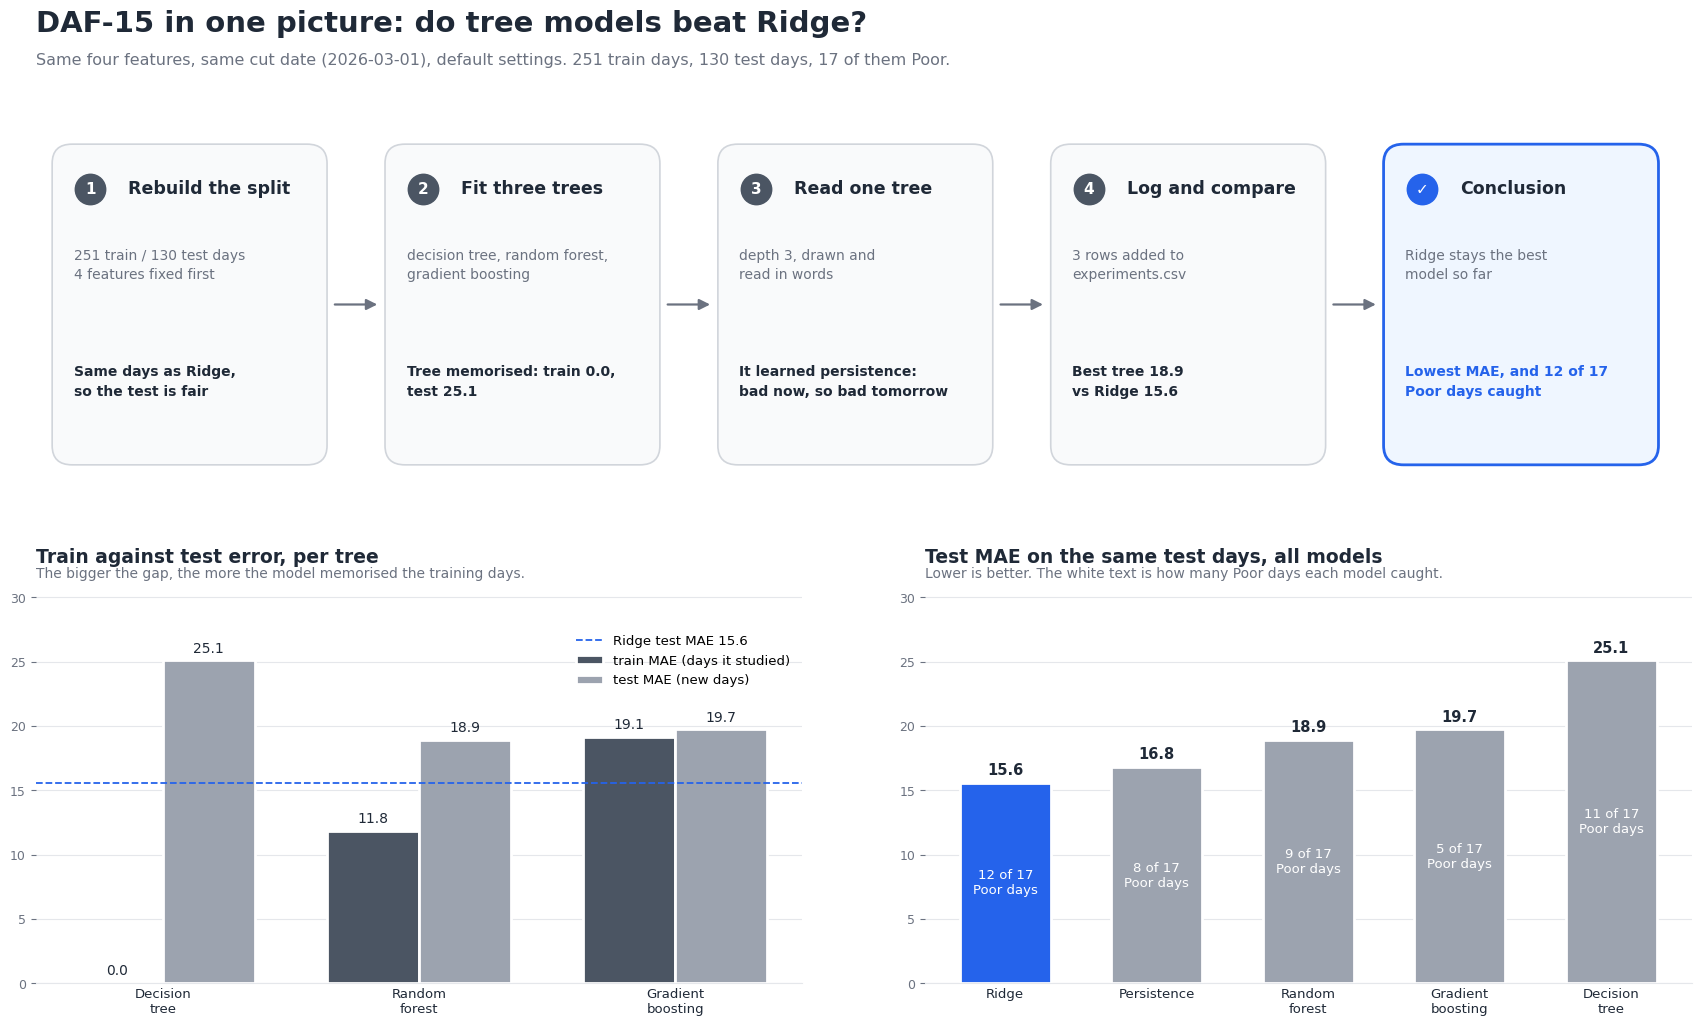

In [5]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

# Continues from Steps 2 and 4: step2_table (train/test MAE per tree) and comparison
# (every model on the same 130 test days). Nothing is typed in by hand.
INK, MUTED, GRID = "#1f2937", "#6b7280", "#e5e7eb"
BAR, BASE_BAR, ACCENT = "#9ca3af", "#4b5563", "#2563eb"
CARD_EDGE, CARD_FILL = "#d1d5db", "#f9fafb"

tree_names = ["decision_tree", "random_forest", "hist_gradient_boosting"]
tree_labels = ["Decision\ntree", "Random\nforest", "Gradient\nboosting"]
n_poor = int((test["target"] >= poor_threshold).sum())
ridge = comparison.loc["daf14_selected"]
best_tree = step2_table["test_mae"].idxmin()

fig = plt.figure(figsize=(18, 11), facecolor="white")
grid = fig.add_gridspec(2, 2, height_ratios=[1, 1.15], hspace=0.34, wspace=0.16, left=0.05, right=0.97, top=0.86, bottom=0.09)
flow = fig.add_subplot(grid[0, :])
flow.set_xlim(0, 100)
flow.set_ylim(1.5, 22.5)
flow.axis("off")

fig.text(0.05, 0.955, "DAF-15 in one picture: do tree models beat Ridge?", fontsize=21, fontweight="bold", color=INK)
fig.text(
    0.05, 0.925,
    f"Same four features, same cut date ({cut_date.date()}), default settings. {len(train)} train days, {len(test)} test days, {n_poor} of them Poor.",
    fontsize=11.5, color=MUTED,
)

cards = [
    ("1", "Rebuild the split", f"{len(train)} train / {len(test)} test days\n4 features fixed first", "Same days as Ridge,\nso the test is fair"),
    ("2", "Fit three trees", "decision tree, random forest,\ngradient boosting", f"Tree memorised: train 0.0,\ntest {step2_table.loc['decision_tree', 'test_mae']:.1f}"),
    ("3", "Read one tree", "depth 3, drawn and\nread in words", "It learned persistence:\nbad now, so bad tomorrow"),
    ("4", "Log and compare", "3 rows added to\nexperiments.csv", f"Best tree {step2_table.loc[best_tree, 'test_mae']:.1f}\nvs Ridge {ridge['mae']:.1f}"),
    ("✓", "Conclusion", "Ridge stays the best\nmodel so far", f"Lowest MAE, and {int(ridge['poor_caught_of_17'])} of {n_poor}\nPoor days caught"),
]
card_w, card_h, gap = 16.6, 20, 3.5
for index, (badge, title, does, shows) in enumerate(cards):
    x = 1 + index * (card_w + gap)
    final = index == len(cards) - 1
    flow.add_patch(
        FancyBboxPatch(
            (x, 2), card_w, card_h, boxstyle="round,pad=0.0,rounding_size=1.2",
            facecolor="#eff6ff" if final else CARD_FILL,
            edgecolor=ACCENT if final else CARD_EDGE, linewidth=2.0 if final else 1.2,
        )
    )
    flow.scatter([x + 2.3], [2 + card_h - 2.8], s=480, color=ACCENT if final else BASE_BAR, zorder=3)
    flow.text(x + 2.3, 2 + card_h - 2.8, badge, ha="center", va="center", fontsize=11, fontweight="bold", color="white", zorder=4)
    flow.text(x + 4.6, 2 + card_h - 2.8, title, ha="left", va="center", fontsize=12.5, fontweight="bold", color=INK)
    flow.text(x + 1.3, 2 + card_h - 6.5, does, ha="left", va="top", fontsize=10, color=MUTED, linespacing=1.5)
    flow.text(x + 1.3, 2 + 5.2, shows, ha="left", va="center", fontsize=10, fontweight="bold", color=ACCENT if final else INK, linespacing=1.5)
    if index < len(cards) - 1:
        flow.annotate(
            "", xy=(x + card_w + gap - 0.3, 2 + card_h / 2), xytext=(x + card_w + 0.3, 2 + card_h / 2),
            arrowprops=dict(arrowstyle="-|>", color=MUTED, lw=1.6, mutation_scale=16),
        )


def style_axis(ax, title, subtitle):
    ax.set_title(title, loc="left", fontsize=13.5, fontweight="bold", color=INK, pad=24)
    ax.text(0, 1.04, subtitle, transform=ax.transAxes, fontsize=10, color=MUTED, va="bottom")
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_color(GRID)
    ax.tick_params(axis="x", length=0, labelsize=9.5, colors=INK)
    ax.tick_params(axis="y", labelsize=9, colors=MUTED)
    ax.grid(axis="y", color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)


# Left: train against test MAE for each tree. The gap is the memorising.
gap_ax = fig.add_subplot(grid[1, 0])
positions = range(len(tree_names))
width = 0.36
train_values = [step2_table.loc[n, "train_mae"] for n in tree_names]
test_values = [step2_table.loc[n, "test_mae"] for n in tree_names]
train_bars = gap_ax.bar([p - width / 2 for p in positions], train_values, width, color=BASE_BAR, label="train MAE (days it studied)", edgecolor="white", linewidth=2)
test_bars = gap_ax.bar([p + width / 2 for p in positions], test_values, width, color=BAR, label="test MAE (new days)", edgecolor="white", linewidth=2)
for bars in (train_bars, test_bars):
    for bar in bars:
        gap_ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4, f"{bar.get_height():.1f}", ha="center", va="bottom", fontsize=10, color=INK)
gap_ax.axhline(ridge["mae"], color=ACCENT, linestyle="--", linewidth=1.3, label=f"Ridge test MAE {ridge['mae']:.1f}")
gap_ax.set_xticks(list(positions), tree_labels)
gap_ax.set_ylim(0, max(test_values) * 1.2)
gap_ax.legend(frameon=False, fontsize=9.5, loc="upper right", bbox_to_anchor=(1, 0.93))
style_axis(gap_ax, "Train against test error, per tree", "The bigger the gap, the more the model memorised the training days.")

# Right: every model on the same 130 test days, with Poor days caught.
rank_ax = fig.add_subplot(grid[1, 1])
ranked = comparison.sort_values("mae")
names = {
    "daf14_selected": "Ridge",
    "persistence (re-scored here)": "Persistence",
    "daf15_random_forest": "Random\nforest",
    "daf15_hist_gradient_boosting": "Gradient\nboosting",
    "daf15_decision_tree": "Decision\ntree",
}
bar_colors = [ACCENT if name == "daf14_selected" else BAR for name in ranked.index]
rank_bars = rank_ax.bar(range(len(ranked)), ranked["mae"], width=0.6, color=bar_colors, edgecolor="white", linewidth=2)
for bar, (_, row) in zip(rank_bars, ranked.iterrows()):
    rank_ax.text(bar.get_x() + bar.get_width() / 2, row["mae"] + 0.4, f"{row['mae']:.1f}", ha="center", va="bottom", fontsize=10.5, fontweight="bold", color=INK)
    rank_ax.text(bar.get_x() + bar.get_width() / 2, row["mae"] / 2, f"{int(row['poor_caught_of_17'])} of {n_poor}\nPoor days", ha="center", va="center", fontsize=9.5, color="white")
rank_ax.set_xticks(range(len(ranked)), [names[n] for n in ranked.index])
rank_ax.set_ylim(0, ranked["mae"].max() * 1.2)
style_axis(rank_ax, "Test MAE on the same test days, all models", "Lower is better. The white text is how many Poor days each model caught.")

fig.savefig(data_root.parent / "notebooks/figures/15_recap.png", dpi=150, bbox_inches="tight")
plt.show()